In [ ]:
#Importing files - api_data_aadhar_enrolment.zip, api_data_aadhar_biometric.zip, api_data_aadhar_demographic.zip
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#unzipping the imported files
!unzip api_data_aadhar_enrolment.zip
!unzip api_data_aadhar_biometric.zip
!unzip api_data_aadhar_demographic.zip

Archive:  api_data_aadhar_enrolment.zip
replace api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
Archive:  api_data_aadhar_biometric.zip
replace api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
Archive:  api_data_aadhar_demographic.zip
replace api_data_aadhar_demographic/api_data_aa

In [ ]:
#Importing Libraries
import pandas as pd
import os
import numpy as np

In [ ]:
#Loading Folder
def load_csv_folder(folder_path):
    dfs = []
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(".csv"):
                dfs.append(
                    pd.read_csv(
                        os.path.join(root, file),
                        low_memory=False
                    )
                )
    return pd.concat(dfs, ignore_index=True)

In [ ]:
enrollment_df   = load_csv_folder("api_data_aadhar_enrolment/")
biometric_df    = load_csv_folder("api_data_aadhar_biometric/")
demographic_df  = load_csv_folder("api_data_aadhar_demographic/")

In [ ]:
#Metadata
print(enrollment_df.shape)
print(biometric_df.shape)
print(demographic_df.shape)

enrollment_df.head()

(1006029, 7)
(1861108, 6)
(2071700, 6)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
0,31-12-2025,Karnataka,Bidar,585330,2,3,0
1,31-12-2025,Karnataka,Bidar,585402,6,0,0
2,31-12-2025,Karnataka,Bidar,585413,1,0,0
3,31-12-2025,Karnataka,Bidar,585418,1,2,0
4,31-12-2025,Karnataka,Bidar,585421,4,3,0


In [ ]:
biometric_df.head()

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,07-11-2025,Haryana,Yamuna Nagar,135002,4,6
1,07-11-2025,Haryana,Yamunanagar,135001,1,2
2,07-11-2025,Himachal Pradesh,Bilaspur,174004,2,2
3,07-11-2025,Himachal Pradesh,Bilaspur,174005,1,0
4,07-11-2025,Himachal Pradesh,Bilaspur,174013,3,1


In [ ]:
demographic_df.head()

,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,18-11-2025,Karnataka,Hasan,573118,0,2
1,18-11-2025,Karnataka,Hasan,573124,1,3
2,18-11-2025,Karnataka,Hasan,573150,0,2
3,18-11-2025,Karnataka,Hassan,573113,0,1
4,18-11-2025,Karnataka,Hassan,573120,1,4


In [ ]:
#Data Cleaning
##Duplicate Values of Enrollment dataset
enrollment_df.duplicated().sum()

np.int64(22957)

In [ ]:
duplicate_rows1 = enrollment_df[enrollment_df.duplicated(keep=False)]
duplicate_rows1

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
499,31-12-2025,Madhya Pradesh,Rajgarh,465667,27,6,0
500,31-12-2025,Madhya Pradesh,Rajgarh,465674,23,17,0
501,31-12-2025,Madhya Pradesh,Rajgarh,465677,20,11,0
502,31-12-2025,Madhya Pradesh,Rajgarh,465679,21,8,1
503,31-12-2025,Madhya Pradesh,Ratlam,457001,25,18,2
...,...,...,...,...,...,...,...
1006024,31-12-2025,Telangana,Hyderabad,500045,4,5,1
1006025,31-12-2025,Telangana,Hyderabad,500057,0,2,0
1006026,31-12-2025,Telangana,Hyderabad,500061,4,2,0
1006027,31-12-2025,Telangana,Hyderabad,500062,1,4,0


In [ ]:
enrollment_df_clean = enrollment_df.drop_duplicates(keep="first")

In [ ]:
enrollment_df_clean.duplicated().sum()

np.int64(0)

In [ ]:
print("Before:", enrollment_df.shape)
print("After :", enrollment_df_clean.shape)

Before: (1006029, 7)
After : (983072, 7)


In [ ]:
##Inconsistency in State names
cols = ['date', 'district', 'pincode']

duplicate_rows2 = enrollment_df_clean[enrollment_df_clean.duplicated(subset=cols, keep=False)]

duplicate_rows2.sort_values(by = cols).tail(20)


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater
998060,31-12-2025,Andhra Pradesh,Nizamabad,503245,0,2,0
1003438,31-12-2025,Telangana,Nizamabad,503245,1,3,0
989,31-12-2025,Odisha,Puri,752014,3,1,0
1001933,31-12-2025,Orissa,Puri,752014,0,1,0
996386,31-12-2025,Orissa,Puri,752016,1,0,0
999971,31-12-2025,Odisha,Puri,752016,4,1,0
4628,31-12-2025,Orissa,Rayagada,765001,0,1,0
996354,31-12-2025,Odisha,Rayagada,765001,1,3,0
1001900,31-12-2025,Odisha,Rayagada,765002,0,4,0
1001934,31-12-2025,Orissa,Rayagada,765002,0,2,0


In [ ]:
enrollment_df_clean['state'].value_counts()

,count
state,
Uttar Pradesh,108066
Tamil Nadu,90388
Maharashtra,75531
West Bengal,75329
Karnataka,68787
Andhra Pradesh,63832
Bihar,58542
Rajasthan,54864
Madhya Pradesh,49562


Inconsistency in state names


In [ ]:
##Cleaning state name inconsistencies
!pip install rapidfuzz

In [ ]:
from rapidfuzz import process, fuzz

In [ ]:
enrollment_df_clean = enrollment_df_clean[enrollment_df_clean['state'].apply(lambda x: isinstance(x, str))]


In [ ]:
enrollment_df_clean['state_norm'] = (
    enrollment_df_clean['state']
    .str.lower()
    .str.strip()
    .str.replace('&', 'and', regex=False)
    .str.replace(r'\s+', ' ', regex=True)
)


In [ ]:
canonical_states = [
    'andhra pradesh',
    'arunachal pradesh',
    'assam',
    'bihar',
    'chandigarh',
    'chhattisgarh',
    'delhi',
    'goa',
    'gujarat',
    'haryana',
    'himachal pradesh',
    'jharkhand',
    'karnataka',
    'kerala',
    'ladakh',
    'lakshadweep',
    'madhya pradesh',
    'maharashtra',
    'manipur',
    'meghalaya',
    'mizoram',
    'nagaland',
    'odisha',
    'puducherry',
    'punjab',
    'rajasthan',
    'sikkim',
    'tamil nadu',
    'telangana',
    'tripura',
    'uttar pradesh',
    'uttarakhand',
    'west bengal',
    'andaman and nicobar islands',
    'jammu and kashmir',
    'dadra and nagar haveli and daman and diu'
]


In [ ]:
unique_states = enrollment_df_clean['state_norm'].unique()

matches = []
for state in unique_states:
    match, score, _ = process.extractOne(
        state,
        canonical_states,
        scorer=fuzz.token_sort_ratio
    )
    matches.append((state, match, score))

match_df = pd.DataFrame(
    matches,
    columns=['original', 'matched_state', 'score']
)


In [ ]:
match_df.sample(10)

,original,matched_state,score
26,chandigarh,chandigarh,100.000000
42,west bangal,west bengal,90.909091
33,himachal pradesh,himachal pradesh,100.000000
34,jammu and kashmir,jammu and kashmir,100.000000
10,odisha,odisha,100.000000
22,andhra pradesh,andhra pradesh,100.000000
41,100000,andhra pradesh,0.000000
14,rajasthan,rajasthan,100.000000
28,daman and diu,andaman and nicobar islands,60.000000
32,haryana,haryana,100.000000


In [ ]:
AUTO_THRESHOLD = 90

auto_map = match_df[match_df['score'] >= AUTO_THRESHOLD]


In [ ]:
auto_map.sample(10)

,original,matched_state,score
26,chandigarh,chandigarh,100.0
34,jammu and kashmir,jammu and kashmir,100.0
12,puducherry,puducherry,100.0
33,himachal pradesh,himachal pradesh,100.0
17,telangana,telangana,100.0
25,bihar,bihar,100.0
10,odisha,odisha,100.0
32,haryana,haryana,100.0
39,andaman and nicobar islands,andaman and nicobar islands,100.0
2,ladakh,ladakh,100.0


In [ ]:
fuzzy_mapping = dict(
    zip(auto_map['original'], auto_map['matched_state'])
)


In [ ]:
enrollment_df_clean['state_clean'] = enrollment_df_clean['state_norm'].map(fuzzy_mapping)
enrollment_df_clean['state_clean'] = enrollment_df_clean['state_clean'].fillna(enrollment_df_clean['state_norm'])


In [ ]:
enrollment_df_clean.loc[
    enrollment_df_clean['state_norm'].str.contains('orissa'),
    'state_clean'
] = 'odisha'

enrollment_df_clean.loc[
    enrollment_df_clean['state_norm'].str.contains('pondicherry'),
    'state_clean'
] = 'puducherry'

enrollment_df_clean.loc[
    enrollment_df_clean['state_norm'].str.contains('dadra|daman'),
    'state_clean'
] = 'dadra and nagar haveli and daman and diu'


In [ ]:
enrollment_df_clean['state_final'] = enrollment_df_clean['state_clean'].str.title()


In [ ]:
print("Unique states BEFORE cleaning:", enrollment_df_clean['state'].nunique())
print("Unique states AFTER cleaning :", enrollment_df_clean['state_final'].nunique())

enrollment_df_clean['state_final'].value_counts()


Unique states BEFORE cleaning: 55
Unique states AFTER cleaning : 37


,count
state_final,
Uttar Pradesh,108066
Tamil Nadu,90388
Maharashtra,75531
West Bengal,75364
Karnataka,68787
Andhra Pradesh,63837
Bihar,58542
Rajasthan,54864
Madhya Pradesh,49562


In [ ]:
###Cleaning invalid states
enrollment_df_clean[
    enrollment_df_clean['state_final'].str.fullmatch(r'\d+')
]


,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,state_norm,state_clean,state_final
29137,02-09-2025,100000,100000,100000,0,0,3,100000,100000,100000
52975,03-09-2025,100000,100000,100000,0,0,1,100000,100000,100000
103845,08-09-2025,100000,100000,100000,0,0,1,100000,100000,100000
121827,09-09-2025,100000,100000,100000,0,0,1,100000,100000,100000
159185,11-09-2025,100000,100000,100000,0,0,2,100000,100000,100000
166224,12-09-2025,100000,100000,100000,0,0,2,100000,100000,100000
267807,19-09-2025,100000,100000,100000,0,0,1,100000,100000,100000
278760,20-09-2025,100000,100000,100000,0,0,1,100000,100000,100000
476963,24-10-2025,100000,100000,100000,0,1,0,100000,100000,100000
768773,15-11-2025,100000,100000,100000,0,0,3,100000,100000,100000


In [ ]:
len(enrollment_df_clean[enrollment_df_clean['state_final'] == '100000']) / len(enrollment_df_clean)


2.1361609322613196e-05

In [ ]:
enrollment_df_clean = enrollment_df_clean[
    ~enrollment_df_clean['state_final'].str.fullmatch(r'\d+')
]


In [ ]:
enrollment_df_clean.loc[
    enrollment_df_clean['state_final'].str.lower() == 'westbengal',
    'state_final'
] = 'West Bengal'


In [ ]:
print("Unique states AFTER FINAL cleaning:",
      enrollment_df_clean['state_final'].nunique())

enrollment_df_clean['state_final'].value_counts()


Unique states AFTER FINAL cleaning: 35


,count
state_final,
Uttar Pradesh,108066
Tamil Nadu,90388
Maharashtra,75531
West Bengal,75371
Karnataka,68787
Andhra Pradesh,63837
Bihar,58542
Rajasthan,54864
Madhya Pradesh,49562


Andaman and Nicobar Islands is missing

In [ ]:
enrollment_df_clean.loc[
    enrollment_df_clean['state_norm'].str.contains('andaman'),
    'state_final'
] = 'Andaman And Nicobar Islands'


In [ ]:
enrollment_df_clean['state_final'].nunique()


36

In [ ]:
enrollment_df_clean.sample(10)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,state_norm,state_clean,state_final
413401,17-10-2025,Uttar Pradesh,Faizabad,224208,0,2,0,uttar pradesh,uttar pradesh,Uttar Pradesh
803326,18-11-2025,Uttar Pradesh,Bijnor,246736,1,0,0,uttar pradesh,uttar pradesh,Uttar Pradesh
365532,13-10-2025,Rajasthan,Ganganagar,335051,3,2,0,rajasthan,rajasthan,Rajasthan
476258,24-10-2025,Orissa,Dhenkanal,759025,1,0,0,orissa,odisha,Odisha
836543,25-11-2025,Telangana,Karimnagar,505481,1,0,0,telangana,telangana,Telangana
274759,20-09-2025,Uttar Pradesh,Deoria,274205,1,0,0,uttar pradesh,uttar pradesh,Uttar Pradesh
470231,23-10-2025,Delhi,North West Delhi,110036,1,0,0,delhi,delhi,Delhi
349023,26-09-2025,Uttar Pradesh,Moradabad,244601,5,0,0,uttar pradesh,uttar pradesh,Uttar Pradesh
315957,24-09-2025,Rajasthan,Jodhpur,342008,2,1,0,rajasthan,rajasthan,Rajasthan
344347,26-09-2025,West Bengal,Cooch Behar,736145,1,1,0,west bengal,west bengal,West Bengal


In [ ]:
enrollment_df_clean = enrollment_df_clean.drop(columns=['state_norm', 'state_clean'])

In [ ]:
cols = ['date', 'state_final','district', 'pincode']

duplicate_rows = enrollment_df_clean[enrollment_df_clean.duplicated(subset=cols, keep=False)]

duplicate_rows.sort_values(by = cols).tail(20)

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,state_final
999963,31-12-2025,Odisha,Nayagarh,752026,2,0,0,Odisha
1001932,31-12-2025,Orissa,Nayagarh,752026,0,1,0,Odisha
989,31-12-2025,Odisha,Puri,752014,3,1,0,Odisha
1001933,31-12-2025,Orissa,Puri,752014,0,1,0,Odisha
996386,31-12-2025,Orissa,Puri,752016,1,0,0,Odisha
999971,31-12-2025,Odisha,Puri,752016,4,1,0,Odisha
4628,31-12-2025,Orissa,Rayagada,765001,0,1,0,Odisha
996354,31-12-2025,Odisha,Rayagada,765001,1,3,0,Odisha
1001900,31-12-2025,Odisha,Rayagada,765002,0,4,0,Odisha
1001934,31-12-2025,Orissa,Rayagada,765002,0,2,0,Odisha


In [ ]:
## There are multiple entries for same pincode, state , date , and district this shows that data is uploaded in batches
enrollment_df_aggregated = (
    enrollment_df_clean
    .groupby(
        ['date', 'state_final', 'district', 'pincode'],
        as_index=False
    )
    .agg({
        'age_0_5': 'sum',
        'age_5_17': 'sum',
        'age_18_greater': 'sum'
    })
)


In [ ]:
## Check duplicates again
enrollment_df_aggregated.duplicated(
    subset=['date', 'state_final', 'district', 'pincode']
).sum()


np.int64(0)

In [ ]:
enrollment_df_aggregated.shape[0]

980890

In [ ]:
enrollment_df_aggregated['district'].value_counts()

,count
district,
Pune,6515
North 24 Parganas,6404
Barddhaman,5255
Bengaluru,5216
Hyderabad,4866
...,...
ANGUL,1
KOLKATA,1
Nicobars,1


In [ ]:
enrollment_df_aggregated['district_clean'] = (
    enrollment_df_aggregated['district']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)


In [ ]:
enrollment_df_aggregated['district_clean'].nunique()


963

In [ ]:
(
    enrollment_df_aggregated
    .assign(district_lower=enrollment_df_aggregated['district'].str.lower())
    .groupby('district_lower')['district']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)


,district
district_lower,
jajpur,3
hooghly,3
nadia,3
anugul,2
angul,2
punch,2
aurangabad(bh),2
nuapada,2
dadra and nagar haveli,2


In [ ]:
## Negative values check
enrollment_df_aggregated[
    (enrollment_df_aggregated[['age_0_5','age_5_17','age_18_greater']] < 0).any(axis=1)
]


,date,state_final,district,pincode,age_0_5,age_5_17,age_18_greater,district_clean


In [ ]:
zero_activity = enrollment_df_aggregated[
    (enrollment_df_aggregated[['age_0_5','age_5_17','age_18_greater']].sum(axis=1) == 0)
]

len(zero_activity) / len(enrollment_df_aggregated)


0.0

In [ ]:
invalid_pincodes = enrollment_df_aggregated[
    ~enrollment_df_aggregated['pincode'].astype(str).str.match(r'^[1-9][0-9]{5}$')
]
invalid_pincodes

,date,state_final,district,pincode,age_0_5,age_5_17,age_18_greater,district_clean


In [ ]:
## Districts which are part of more then one state
district_state_counts = (
    enrollment_df_aggregated
    .groupby('district')['state_final']
    .nunique()
    .sort_values(ascending=False)
)

district_state_counts[district_state_counts > 1]


,state_final
district,
Balrampur,2
Kamrup,2
Medak,2
Kargil,2
Karimnagar,2
Hamirpur,2
Aurangabad,2
K.v. Rangareddy,2
Mahabubnagar,2


In [ ]:
enrollment_df_aggregated['district'].value_counts().sort_values()

,count
district,
Beawar,1
Visakhapatanam,1
East Midnapur,1
South 24 parganas,1
Kushi Nagar,1
...,...
Hyderabad,4866
Bengaluru,5216
Barddhaman,5255


In [ ]:
(
    enrollment_df_aggregated
    .groupby(['state_final', 'district'])
    .size()
    .reset_index(name='count')
    .sort_values(['state_final','district'])
)


,state_final,district,count
0,Andaman And Nicobar Islands,Andamans,65
1,Andaman And Nicobar Islands,Nicobar,37
2,Andaman And Nicobar Islands,Nicobars,1
3,Andaman And Nicobar Islands,North And Middle Andaman,96
4,Andaman And Nicobar Islands,South Andaman,171
...,...,...,...
1000,West Bengal,Uttar Dinajpur,1411
1001,West Bengal,West Medinipur,2
1002,West Bengal,West Midnapore,1020
1003,West Bengal,hooghly,10


In [ ]:
##Duplicate rows in Biometric dataset
biometric_df.duplicated().sum()

np.int64(94896)

In [ ]:
duplicate_rows2 = biometric_df[biometric_df.duplicated(keep=False)]
duplicate_rows2

,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,07-11-2025,Haryana,Yamuna Nagar,135002,4,6
1,07-11-2025,Haryana,Yamunanagar,135001,1,2
2,07-11-2025,Himachal Pradesh,Bilaspur,174004,2,2
3,07-11-2025,Himachal Pradesh,Bilaspur,174005,1,0
4,07-11-2025,Himachal Pradesh,Bilaspur,174013,3,1
...,...,...,...,...,...,...
1860707,29-12-2025,Andhra Pradesh,Prakasam,523327,3,7
1860708,29-12-2025,Andhra Pradesh,Prakasam,523368,2,3
1860709,29-12-2025,Andhra Pradesh,Prakasam,523370,1,1
1860710,29-12-2025,Andhra Pradesh,Prakasam,523371,2,1


In [ ]:
biometric_df_clean = biometric_df.drop_duplicates(keep="first")

In [ ]:
biometric_df_clean.duplicated().sum()

np.int64(0)

In [ ]:
print("Before:", biometric_df.shape)
print("After :", biometric_df_clean.shape)

Before: (1861108, 6)
After : (1766212, 6)


In [ ]:
## Inconsistencies in state names
biometric_df_clean.sample()

,date,state,district,pincode,bio_age_5_17,bio_age_17_
1726421,20-12-2025,Punjab,Shaheed Bhagat Singh Nagar,144632,0,1


In [ ]:
print(biometric_df_clean['state'].nunique())
biometric_df_clean['state'].value_counts()

57


,count
state,
Tamil Nadu,174934
Andhra Pradesh,160202
Uttar Pradesh,147138
Maharashtra,143609
Karnataka,135780
West Bengal,125274
Kerala,93951
Gujarat,84630
Odisha,83177


In [ ]:
## Cleaning state name inconsistencies
biometric_df_clean['state_clean'] = (
    biometric_df_clean['state']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)


/tmp/ipython-input-1994279776.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  biometric_df_clean['state_clean'] = (


In [ ]:
STATE_CANONICAL_MAP = {
    # West Bengal
    'west bengal': 'West Bengal',
    'west bangal': 'West Bengal',
    'westbengal': 'West Bengal',

    # Andhra Pradesh
    'andhra pradesh': 'Andhra Pradesh',

    # Odisha
    'orissa': 'Odisha',
    'odisha': 'Odisha',

    # Tamil Nadu
    'tamilnadu': 'Tamil Nadu',

    # Chhattisgarh
    'chhatisgarh': 'Chhattisgarh',

    # Uttarakhand
    'uttaranchal': 'Uttarakhand',

    # Jammu & Kashmir
    'jammu & kashmir': 'Jammu and Kashmir',

    # Andaman & Nicobar Islands
    'andaman & nicobar islands': 'Andaman and Nicobar Islands',
    'andaman and nicobar islands': 'Andaman and Nicobar Islands',

    # Puducherry
    'pondicherry': 'Puducherry',

    # Daman / Dadra merger (CRITICAL)
    'daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman & diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra & nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli and daman and diu':
        'Dadra and Nagar Haveli and Daman and Diu',
    r'\bputtenahalli\b': 'Karnataka',
    r'\bmadanapalle\b': 'Andhra Pradesh',
    r'\braja annamalai puram\b': 'Tamil Nadu',
    r'\bdarbhanga\b': 'Bihar',
    r'\bjaipur\b': 'Rajasthan',
    r'\bnagpur\b': 'Maharashtra',
    r'\bbalanagar\b': 'Telangana',
    r'\bwest bengli\b': 'West Bengal',
    r'\bdadra and nagar haveli and daman and diu and dadra and nagar haveli and daman and diu\b': 'Dadra and Nagar Haveli and Daman and Diu'
}

In [ ]:
biometric_df_clean['state_final'] = (
    biometric_df_clean['state_clean']
    .replace(STATE_CANONICAL_MAP)
    .str.title()
)


/tmp/ipython-input-92544845.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  biometric_df_clean['state_final'] = (


In [ ]:
biometric_df_clean['state_final'].nunique()


36

In [ ]:
biometric_df_clean['state_final'].value_counts().sort_values()


,count
state_final,
Lakshadweep,525
Ladakh,688
Dadra And Nagar Haveli And Daman And Diu,1262
Chandigarh,1576
Andaman And Nicobar Islands,1692
Sikkim,2298
Mizoram,3217
Nagaland,3666
Arunachal Pradesh,3957


In [ ]:
cols = ['date', 'state_final','district', 'pincode']

duplicate_rows = biometric_df_clean[biometric_df_clean.duplicated(subset=cols, keep=False)]

duplicate_rows.sort_values(by = cols).tail(20)

,date,state,district,pincode,bio_age_5_17,bio_age_17_,state_clean,state_final
1334915,31-10-2025,Odisha,Sundargarh,769015,2,2,odisha,Odisha
1346894,31-10-2025,Orissa,Sundargarh,769015,0,1,orissa,Odisha
1334916,31-10-2025,Odisha,Sundargarh,770001,0,1,odisha,Odisha
1356426,31-10-2025,Orissa,Sundargarh,770001,2,2,orissa,Odisha
1334979,31-10-2025,Pondicherry,Karaikal,609602,2,4,pondicherry,Puducherry
1346901,31-10-2025,Puducherry,Karaikal,609602,5,9,puducherry,Puducherry
1334985,31-10-2025,Puducherry,Karaikal,609604,2,1,puducherry,Puducherry
1346895,31-10-2025,Pondicherry,Karaikal,609604,0,4,pondicherry,Puducherry
1346903,31-10-2025,Puducherry,Karaikal,609605,1,1,puducherry,Puducherry
1356427,31-10-2025,Pondicherry,Karaikal,609605,0,1,pondicherry,Puducherry


In [ ]:
biometric_df_aggregated = (
    biometric_df_clean
    .groupby(
        ['date', 'state_final', 'district', 'pincode'],
        as_index=False
    )
    .agg({
        'bio_age_5_17': 'sum',
        'bio_age_17_': 'sum'
    })
)


In [ ]:
biometric_df_aggregated.duplicated(
    subset=['date', 'state_final', 'district', 'pincode']
).sum()


np.int64(0)

In [ ]:
biometric_df_aggregated['district'].sort_values()

,district
1199273,?
1331864,ANGUL
1010884,ANGUL
1183435,ANGUL
1744443,ANGUL
...,...
1697008,yadgir
1697007,yadgir
390216,yadgir
1201532,yadgir


In [ ]:
biometric_df_aggregated['district_clean'] = (
    biometric_df_aggregated['district']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)


In [ ]:
biometric_df_aggregated['district_clean'] = (
    biometric_df_aggregated['district_clean']
    .replace({'?': 'unknown', '': 'unknown', 'nan': 'unknown'})
)

In [ ]:
biometric_df_aggregated.loc[
    biometric_df_aggregated['district_clean'].str.fullmatch(r'\d+'),
    'district_clean'
] = 'unknown'

In [ ]:
biometric_df_aggregated['district_final'] = (
    biometric_df_aggregated['district_clean']
    .str.title())

In [ ]:
unknown_pct = round(
    (biometric_df_aggregated['district_final'] == 'Unknown').mean() * 100,
    6
)

print(f"Unknown district percentage: {unknown_pct}%")

Unknown district percentage: 5.7e-05%


In [ ]:
biometric_df_aggregated.shape[0]

1754080

In [ ]:
biometric_df_aggregated = biometric_df_aggregated.drop('district_clean', axis=1)


In [ ]:
biometric_df_aggregated.sample(10)

,date,state_final,district,pincode,bio_age_5_17,bio_age_17_,district_final
876606,13-09-2025,Maharashtra,Raigarh,402114,5,3,Raigarh
1430327,20-12-2025,Punjab,Jalandhar,144022,9,4,Jalandhar
1117553,16-11-2025,Odisha,Puri,752108,2,1,Puri
159155,01-12-2025,Kerala,Malappuram,676501,1,8,Malappuram
1156628,17-09-2025,Karnataka,Mysore,570021,1,4,Mysore
85480,01-06-2025,Uttar Pradesh,Sitapur,261125,323,93,Sitapur
513088,07-11-2025,Uttar Pradesh,Faizabad,224171,3,6,Faizabad
1289964,18-12-2025,Punjab,Jalandhar,144410,6,3,Jalandhar
700604,10-11-2025,Rajasthan,Ganganagar,335702,4,6,Ganganagar
1664565,28-12-2025,Uttar Pradesh,Bulandshahr,245409,6,3,Bulandshahr


In [ ]:
biometric_df_aggregated= biometric_df_aggregated.drop('district',axis =1)


In [ ]:
biometric_df_aggregated.sample()


,date,state_final,pincode,bio_age_5_17,bio_age_17_,district_final
153533,01-12-2025,Bihar,854318,54,78,Araria


In [ ]:
biometric_df_aggregated = biometric_df_aggregated.rename(columns = {'district_final': 'district'})

In [ ]:
biometric_df_aggregated.sample()

,date,state_final,pincode,bio_age_5_17,bio_age_17_,district
434010,06-09-2025,Madhya Pradesh,461331,6,7,Harda


In [ ]:
enrollment_df_aggregated.sample()

,date,state_final,district,pincode,age_0_5,age_5_17,age_18_greater,district_clean
30318,02-09-2025,Chhattisgarh,Durg,490024,1,1,0,durg


In [ ]:
enrollment_df_aggregated.head(), biometric_df_aggregated.head()


(         date state_final district  pincode  age_0_5  age_5_17  \
 0  01-04-2025       Assam    Baksa   781315      114        32   
 1  01-04-2025       Assam    Baksa   781344       31        29   
 2  01-04-2025       Assam    Baksa   781360       84       192   
 3  01-04-2025       Assam    Baksa   781367       94       121   
 4  01-04-2025       Assam    Baksa   781368       46        71   
 
    age_18_greater district_clean  
 0              18          baksa  
 1              16          baksa  
 2              73          baksa  
 3              31          baksa  
 4              30          baksa  ,
          date                  state_final  pincode  bio_age_5_17  \
 0  01-03-2025  Andaman And Nicobar Islands   744101            16   
 1  01-03-2025  Andaman And Nicobar Islands   744301           101   
 2  01-03-2025  Andaman And Nicobar Islands   744302            15   
 3  01-03-2025  Andaman And Nicobar Islands   744303            46   
 4  01-03-2025  Andaman And N

In [ ]:
#Saving as csv
import os

os.listdir()


['.config',
 'api_data_aadhar_demographic (2).zip',
 'api_data_aadhar_biometric',
 'api_data_aadhar_enrolment (2).zip',
 'api_data_aadhar_demographic',
 'api_data_aadhar_enrolment',
 'api_data_aadhar_biometric (2).zip',
 'api_data_aadhar_enrolment (1).zip',
 'api_data_aadhar_enrolment.zip',
 'api_data_aadhar_biometric (1).zip',
 'api_data_aadhar_biometric.zip',
 'api_data_aadhar_demographic.zip',
 'api_data_aadhar_demographic (1).zip',
 'enrollment_df_aggregated.csv',
 'sample_data']

In [ ]:
enrollment_df_aggregated.to_csv("enrollment_df_aggregated.csv", index=False)


In [ ]:
#files.download("enrollment_df_aggregated.csv")

In [ ]:
key_cols = ['state_final', 'district', 'date']

print("Enrolment nulls:")
print(enrollment_df_aggregated[key_cols].isna().sum())

print("\nBiometric nulls:")
print(biometric_df_aggregated[key_cols].isna().sum())


Enrolment nulls:
state_final    0
district       0
date           0
dtype: int64

Biometric nulls:
state_final    0
district       0
date           0
dtype: int64


In [ ]:
print(enrollment_df_aggregated.columns)
print(biometric_df_aggregated.columns)


Index(['date', 'state_final', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater', 'district_clean'],
      dtype='object')
Index(['date', 'state_final', 'pincode', 'bio_age_5_17', 'bio_age_17_',
       'district'],
      dtype='object')


In [ ]:
enrollment_df_aggregated['total_enrolments'] = (
    enrollment_df_aggregated['age_0_5'] +
    enrollment_df_aggregated['age_5_17'] +
    enrollment_df_aggregated['age_18_greater']
)


In [ ]:
enrollment_df_aggregated[['age_0_5','age_5_17','age_18_greater','total_enrolments']].head()


,age_0_5,age_5_17,age_18_greater,total_enrolments
0,114,32,18,164
1,31,29,16,76
2,84,192,73,349
3,94,121,31,246
4,46,71,30,147


In [ ]:
biometric_df_aggregated['biometric_updates'] = (
    biometric_df_aggregated['bio_age_5_17'] +
    biometric_df_aggregated['bio_age_17_']
)


In [ ]:
biometric_df_aggregated[['bio_age_5_17','bio_age_17_','biometric_updates']].head()


,bio_age_5_17,bio_age_17_,biometric_updates
0,16,193,209
1,101,48,149
2,15,12,27
3,46,27,73
4,16,14,30


In [ ]:
enrollment_df_aggregated['date'].isna().mean(), biometric_df_aggregated['date'].isna().mean()

(np.float64(0.0), np.float64(0.0))

In [ ]:
enrollment_df_aggregated['date'].dtype
biometric_df_aggregated['date'].dtype


dtype('O')

In [ ]:
enrollment_df_aggregated['date'] = pd.to_datetime(enrollment_df_aggregated['date'],format='%d-%m-%Y')

In [ ]:
enrollment_df_aggregated['date'].isna().mean()

np.float64(0.0)

In [ ]:
biometric_df_aggregated['date'] = pd.to_datetime(biometric_df_aggregated['date'],format='%d-%m-%Y')
biometric_df_aggregated['date'].isna().mean()

np.float64(0.0)

In [ ]:
enrollment_df_aggregated['date'].dtype
biometric_df_aggregated['date'].dtype


dtype('<M8[ns]')

In [ ]:
enrollment_df_aggregated[['state_final','district','date']].head()


,state_final,district,date
0,Assam,Baksa,2025-04-01
1,Assam,Baksa,2025-04-01
2,Assam,Baksa,2025-04-01
3,Assam,Baksa,2025-04-01
4,Assam,Baksa,2025-04-01


In [ ]:
enrollment_df_aggregated.groupby(['state_final','district']).size().describe()


,0
count,1005.000000
mean,976.009950
std,1003.538733
min,1.000000
25%,198.000000
50%,704.000000
75%,1381.000000
max,6515.000000


In [ ]:
##Duplicate values of Demographic dataset
demographic_df.duplicated().sum()

np.int64(473601)

In [ ]:
duplicate_rows3 = demographic_df[demographic_df.duplicated(keep=False)]
duplicate_rows3

,date,state,district,pincode,demo_age_5_17,demo_age_17_
0,18-11-2025,Karnataka,Hasan,573118,0,2
1,18-11-2025,Karnataka,Hasan,573124,1,3
2,18-11-2025,Karnataka,Hasan,573150,0,2
3,18-11-2025,Karnataka,Hassan,573113,0,1
4,18-11-2025,Karnataka,Hassan,573120,1,4
...,...,...,...,...,...,...
2064223,17-09-2025,Telangana,Nizamabad,503110,0,2
2064224,17-09-2025,Telangana,Nizamabad,503202,2,9
2064225,17-09-2025,Telangana,Nizamabad,503217,2,5
2064226,17-09-2025,Telangana,Nizamabad,503305,0,12


In [ ]:
demographic_df_clean = demographic_df.drop_duplicates(keep="first")

In [ ]:
demographic_df_clean.duplicated().sum()

np.int64(0)

In [ ]:
print("Before:", demographic_df.shape)
print("After :", demographic_df_clean.shape)

Before: (2071700, 6)
After : (1598099, 6)


In [ ]:
##Inconsistencies in State names
demographic_df_clean.sample()

,date,state,district,pincode,demo_age_5_17,demo_age_17_
1466508,14-09-2025,Maharashtra,Nashik,423212,2,2


In [ ]:
#print(demographic_df_clean['state'].nunique())
demographic_df_clean['state'].value_counts()

,count
state,
Andhra Pradesh,154753
Tamil Nadu,153333
Uttar Pradesh,132366
Maharashtra,126303
West Bengal,124694
...,...
Jaipur,1
Nagpur,1
Raja Annamalai Puram,1


In [ ]:
##Cleaning State name inconsistencies
demographic_df_clean['state_clean'] = (
    demographic_df_clean['state']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)

/tmp/ipython-input-908694658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  demographic_df_clean['state_clean'] = (


In [ ]:
cols = ['date', 'district', 'pincode']

duplicate_rows2 = demographic_df_clean[demographic_df_clean.duplicated(subset=cols, keep=False)]

duplicate_rows2.sort_values(by = cols).tail(20)


,date,state,district,pincode,demo_age_5_17,demo_age_17_,state_clean
332714,31-10-2025,Telangana,Warangal,506332,0,7,telangana
1149912,31-10-2025,Andhra Pradesh,Warangal,506332,0,4,andhra pradesh
291914,31-10-2025,Andhra Pradesh,Warangal,506342,0,10,andhra pradesh
332715,31-10-2025,Telangana,Warangal,506342,1,2,telangana
291915,31-10-2025,Andhra Pradesh,Warangal,506343,1,3,andhra pradesh
912603,31-10-2025,Telangana,Warangal,506343,2,4,telangana
332716,31-10-2025,Telangana,Warangal,506348,1,2,telangana
1533974,31-10-2025,Andhra Pradesh,Warangal,506348,1,7,andhra pradesh
912604,31-10-2025,Telangana,Warangal,506349,4,8,telangana
1533975,31-10-2025,Andhra Pradesh,Warangal,506349,1,9,andhra pradesh


In [ ]:
demographic_df_clean['state_clean'].nunique()

57

In [ ]:
# Show all rows where Location column equals '100000'
demographic_df_clean[demographic_df_clean['state_clean'] == '100000']

,date,state,district,pincode,demo_age_5_17,demo_age_17_,state_clean
1007370,20-12-2025,100000,100000,100000,0,1,100000
1366861,23-12-2025,100000,100000,100000,0,1,100000


In [ ]:
demographic_df_clean = demographic_df_clean[demographic_df_clean['state_clean'] != '100000']

In [ ]:
demographic_df_clean[demographic_df_clean['state_clean'] == '100000']

,date,state,district,pincode,demo_age_5_17,demo_age_17_,state_clean


In [ ]:
demographic_df_clean.loc[:, 'state_final'] = (
    demographic_df_clean['state_clean']
    .astype(str)
    .replace(STATE_CANONICAL_MAP, regex=True)
    .str.title()
)

In [ ]:
demographic_df_clean.loc[:, 'state_final'] = (
    demographic_df_clean['state_final']
    .replace(
        {
            r'.*Daman And Diu.*': 'Dadra And Nagar Haveli And Daman And Diu',
            r'.*Dadra And Nagar Haveli.*': 'Dadra And Nagar Haveli And Daman And Diu',
        },
        regex=True
    )
)

In [ ]:
demographic_df_clean['state_final'].value_counts().count()

np.int64(36)

In [ ]:
demographic_df_clean['state_final'].value_counts()

,count
state_final,
Andhra Pradesh,154791
Tamil Nadu,153334
Uttar Pradesh,132366
Maharashtra,126304
West Bengal,125028
Karnataka,120417
Odisha,82498
Kerala,82186
Gujarat,75161


In [ ]:
cols = ['date', 'state_final','district', 'pincode']

duplicate_rows = demographic_df_clean[demographic_df_clean.duplicated(subset=cols, keep=False)]

duplicate_rows.sort_values(by = cols).tail(20)

,date,state,district,pincode,demo_age_5_17,demo_age_17_,state_clean,state_final
913938,31-10-2025,Orissa,Sundargarh,769042,0,1,orissa,Odisha
1856714,31-10-2025,Odisha,Sundargarh,769042,0,4,odisha,Odisha
335217,31-10-2025,Odisha,Sundargarh,770033,0,8,odisha,Odisha
922212,31-10-2025,Orissa,Sundargarh,770033,0,4,orissa,Odisha
335268,31-10-2025,Pondicherry,Karaikal,609601,0,1,pondicherry,Puducherry
1856776,31-10-2025,Puducherry,Karaikal,609601,2,0,puducherry,Puducherry
1856773,31-10-2025,Pondicherry,Karaikal,609607,0,3,pondicherry,Puducherry
1856777,31-10-2025,Puducherry,Karaikal,609607,3,6,puducherry,Puducherry
335270,31-10-2025,Pondicherry,Karaikal,609609,0,1,pondicherry,Puducherry
335278,31-10-2025,Puducherry,Karaikal,609609,1,9,puducherry,Puducherry


In [ ]:
demographic_df_aggregated = (
    demographic_df_clean
    .groupby(
        ['date', 'state_final', 'district', 'pincode'],
        as_index=False
    )
    .agg({
        'demo_age_5_17': 'sum',
        'demo_age_17_': 'sum'
    })
)

In [ ]:
demographic_df_aggregated.duplicated(
    subset=['date', 'state_final', 'district', 'pincode']
).sum()

np.int64(0)

In [ ]:
demographic_df_aggregated['district'].sort_values()

,district
1109328,5th cross
699743,ANGUL
1369726,ANGUL
1059658,ANGUL
510950,ANGUL
...,...
978747,yadgir
1523603,yadgir
1523602,yadgir
491433,yadgir


In [ ]:
demographic_df_aggregated['district_clean'] = (
    demographic_df_aggregated['district']
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r'\s+', ' ', regex=True)
)

In [ ]:
demographic_df_aggregated['district_clean'] = (
    demographic_df_aggregated['district_clean']
    .replace({'?': 'unknown', '': 'unknown', 'nan': 'unknown'})
)

In [ ]:
demographic_df_aggregated.loc[
    demographic_df_aggregated['district_clean'].str.fullmatch(r'\d+'),
    'district_clean'
] = 'unknown'

In [ ]:
demographic_df_aggregated['district_final'] = (
    demographic_df_aggregated['district_clean']
    .str.title())

In [ ]:
unknown_pct = round(
    (demographic_df_aggregated['district_final'] == 'Unknown').mean() * 100,
    6
)

print(f"Unknown district percentage: {unknown_pct}%")

Unknown district percentage: 0.0%


In [ ]:
demographic_df_aggregated.shape[0]

1589284

In [ ]:
demographic_df_aggregated = demographic_df_aggregated.drop('district_clean', axis=1)

In [ ]:
demographic_df_aggregated.sample(10)

,date,state_final,district,pincode,demo_age_5_17,demo_age_17_,district_final
1025489,18-11-2025,Karnataka,Kolar,563121,1,6,Kolar
1073323,19-10-2025,Karnataka,Chamrajanagar,571444,0,7,Chamrajanagar
20935,01-09-2025,Gujarat,Amreli,364490,0,1,Amreli
32920,01-09-2025,Uttar Pradesh,Firozabad,205152,8,22,Firozabad
167292,03-12-2025,Karnataka,Hasan,573162,0,1,Hasan
304922,06-09-2025,Uttar Pradesh,Prayagraj,228411,2,1,Prayagraj
266658,05-11-2025,Madhya Pradesh,Satna,485446,5,27,Satna
164372,03-12-2025,Gujarat,Kachchh,370510,2,8,Kachchh
939300,17-09-2025,Gujarat,Valsad,396230,0,3,Valsad
1276126,24-10-2025,Tamil Nadu,Vellore,635811,0,2,Vellore


In [ ]:
demographic_df_aggregated= demographic_df_aggregated.drop('district',axis =1)

In [ ]:
demographic_df_aggregated.sample()

,date,state_final,pincode,demo_age_5_17,demo_age_17_,district_final
762886,14-11-2025,Telangana,508377,0,7,Nalgonda


In [ ]:
demographic_df_aggregated = demographic_df_aggregated.rename(columns = {'district_final': 'district'})

In [ ]:
demographic_df_aggregated.sample()

,date,state_final,pincode,demo_age_5_17,demo_age_17_,district
217661,04-11-2025,Telangana,508223,0,1,Suryapet


In [ ]:
#Saving as csv
demographic_df_aggregated.to_csv("demographic_df_aggregated.csv", index=False)

In [ ]:
#files.download("demographic_df_aggregated.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

From thisStep  we proved:
- Each district appears many times
- Reporting frequency varies wildly (1 to 6500+ rows)

If we don’t collapse time:
- Districts with more reporting days dominate
- Map becomes a reporting-frequency map, not an Aadhaar activity map

In [ ]:
#Further data check (testing)
enrol_dist_cum = (
    enrollment_df_aggregated
    .groupby(['state_final', 'district'], as_index=False)
    .agg({
        'age_0_5': 'sum',
        'age_5_17': 'sum',
        'age_18_greater': 'sum',
        'total_enrolments': 'sum'
    })
)


In [ ]:
biom_dist_cum = (
    biometric_df_aggregated
    .groupby(['state_final', 'district'], as_index=False)
    .agg({
        'bio_age_5_17': 'sum',
        'bio_age_17_': 'sum',
        'biometric_updates': 'sum'
    })
)


In [ ]:
enrol_dist_cum.shape, biom_dist_cum.shape


In [ ]:
(enrol_dist_cum.select_dtypes('number') < 0).any()
(biom_dist_cum.select_dtypes('number') < 0).any()


In [ ]:
enrol_dist_cum.head(),biom_dist_cum.head()


In [ ]:
district_df = enrol_dist_cum.merge(
    biom_dist_cum,
    on=['state_final', 'district'],
    how='left',
    indicator=True
)


In [ ]:
district_df['_merge'].value_counts()


In [ ]:
district_df[district_df['_merge'] == 'left_only'].head()


In [ ]:
district_df.drop(columns=['_merge'], inplace=True)


In [ ]:
district_df['comparable_enrolments'] = (
    district_df['age_5_17'] + district_df['age_18_greater']
)

district_df['comparable_bio_updates'] = (
    district_df['bio_age_5_17'].fillna(0) +
    district_df['bio_age_17_'].fillna(0)
)


In [ ]:
(district_df['comparable_enrolments'] < 0).any(),(district_df['comparable_bio_updates'] < 0).any()


In [ ]:
(district_df['comparable_enrolments'] == 0).sum()


In [ ]:
district_df[
    district_df['comparable_enrolments'] == 0
][['state_final','district','age_5_17','age_18_greater']].head()


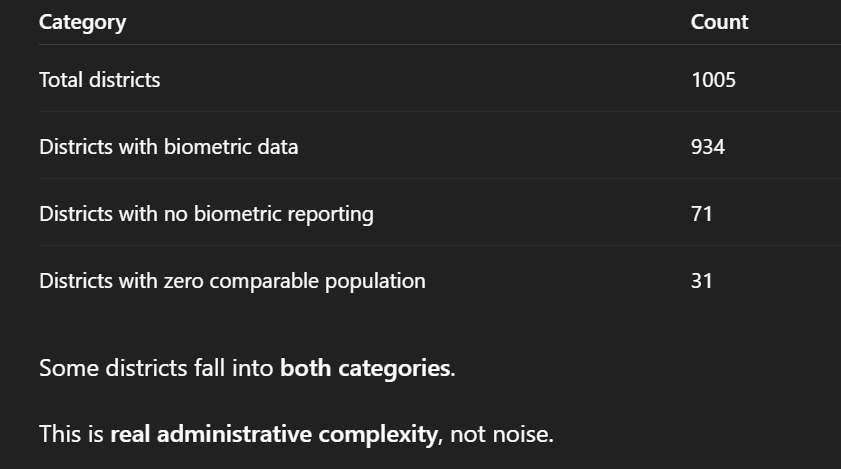

In [ ]:
district_df['has_comparable_population'] = (
    district_df['comparable_enrolments'] > 0
)

district_df['has_biometric_reporting'] = (
    district_df['biometric_updates'].notna()
)


In [ ]:
district_df['bio_update_rate'] = None

mask = district_df['has_comparable_population']

district_df.loc[mask, 'bio_update_rate'] = (
    district_df.loc[mask, 'comparable_bio_updates'] /
    district_df.loc[mask, 'comparable_enrolments']
)


In [ ]:
district_df['bio_update_rate'].isna().sum()


In [ ]:
district_df['bio_update_rate'].dropna().describe()


In [ ]:
district_df.sort_values('bio_update_rate').head(10)[
    ['state_final','district','bio_update_rate',
     'comparable_enrolments','comparable_bio_updates']
]


In [ ]:
min_pop_threshold = (
    district_df.loc[
        district_df['has_comparable_population'],
        'comparable_enrolments'
    ].quantile(0.10)
)

min_pop_threshold


In [ ]:
district_df['is_statistically_valid'] = (
    district_df['comparable_enrolments'] >= min_pop_threshold
)


In [ ]:
district_df['is_statistically_valid'].value_counts()


In [ ]:
analysis_mask = (
    district_df['has_comparable_population'] &
    district_df['is_statistically_valid']
)


In [ ]:
state_stats = (
    district_df[analysis_mask]
    .groupby('state_final')['bio_update_rate']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'state_mean', 'std': 'state_std'})
)


In [ ]:
district_df = district_df.merge(
    state_stats,
    on='state_final',
    how='left'
)


In [ ]:
district_df['z_score'] = None

district_df.loc[analysis_mask, 'z_score'] = (
    (district_df.loc[analysis_mask, 'bio_update_rate'] -
     district_df.loc[analysis_mask, 'state_mean']) /
    district_df.loc[analysis_mask, 'state_std']
)


In [ ]:
district_df['z_score'].isna().sum()


In [ ]:
district_df['z_score'].dropna().describe()


In [ ]:
district_df['under_activity_flag'] = (
    district_df['z_score'] < -1.5
)


In [ ]:
def assign_status(row):
    if not row['has_comparable_population']:
        return 'Insufficient eligible population'
    if not row['is_statistically_valid']:
        return 'Low-signal (small population)'
    if row['has_comparable_population'] and row['comparable_bio_updates'] == 0:
        return 'No biometric reporting'
    if row['z_score'] < -1.5:
        return 'Under-activity (High priority)'
    if row['z_score'] < 0:
        return 'Below state average'
    return 'At or above state average'


district_df['district_status'] = district_df.apply(assign_status, axis=1)


In [ ]:
district_df['district_status'].value_counts()


In [ ]:
map_df = district_df[[
    'state_final',
    'district',
    'district_status'
]].copy()


In [ ]:
print(map_df.shape)
map_df.head()


In [ ]:
files

In [ ]:
# Run in Colab
import glob, os, textwrap

candidates = glob.glob("**/*.geojson", recursive=True) + \
             glob.glob("**/*.json", recursive=True) + \
             glob.glob("**/*.shp", recursive=True)

print("Found geo-related files (first 50):")
for p in candidates[:50]:
    print(p)
print("\nCurrent working dir:", os.getcwd())


In [ ]:
import geopandas as gpd

gdf = gpd.read_file("2011_Dist.shp")

gdf.shape


In [ ]:
gdf.columns


In [ ]:
for col in gdf.columns:
    if 'dist' in col.lower() or 'name' in col.lower():
        print(col, gdf[col].head(5).tolist())


In [ ]:
import re

def normalize_name(s):
    s = str(s).lower().strip()
    s = re.sub(r'\(.*?\)', '', s)        # remove brackets
    s = re.sub(r'[^a-z\s]', ' ', s)      # remove punctuation
    s = re.sub(r'\s+', ' ', s)
    return s

# Normalize shapefile districts
gdf['district_norm'] = gdf['DISTRICT'].apply(normalize_name)

# Normalize UIDAI districts
map_df = district_df[['state_final','district','district_status']].copy()
map_df['district_norm'] = map_df['district'].apply(normalize_name)


In [ ]:
data_districts = set(map_df['district_norm'])
geo_districts = set(gdf['district_norm'])

print("UIDAI districts:", len(data_districts))
print("Census districts:", len(geo_districts))
print("Unmatched UIDAI → Census:", len(data_districts - geo_districts))


In [ ]:
list(data_districts - geo_districts)[:20]


In [ ]:
map_df['is_mappable_2011'] = (
    map_df['district_norm'].isin(geo_districts)
)

map_df['is_mappable_2011'].value_counts()


In [ ]:
gdf_map = gdf.merge(
    map_df[map_df['is_mappable_2011']][
        ['district_norm', 'district_status']
    ],
    on='district_norm',
    how='left'
)


In [ ]:
gdf_map['district_status'].value_counts(dropna=False)


“Note: District boundaries are based on Census 2011. Districts created after 2011 are excluded from the map but included in tabular analysis.”

In [ ]:
#Map display/analytics
gdf_map['district_status'] = gdf_map['district_status'].fillna(
    'No UIDAI data (mapped boundary only)'
)


In [ ]:
gdf_map['district_status'].value_counts()


In [ ]:
color_map = {
    'Under-activity (High priority)': '#b30000',
    'No biometric reporting': '#e34a33',
    'Below state average': '#fdbb84',
    'At or above state average': '#31a354',
    'Low-signal (small population)': '#bdbdbd',
    'Insufficient eligible population': '#d9d9d9',
    'No UIDAI data (mapped boundary only)': '#f0f0f0'
}


In [ ]:
import json

geojson_map = json.loads(gdf_map.to_json())


In [ ]:
legend_order = [
    'Under-activity (High priority)',
    'No biometric reporting',
    'Below state average',
    'At or above state average',
    'Low-signal (small population)',
    'Insufficient eligible population',
    'No UIDAI data (mapped boundary only)'
]


In [ ]:
color_map = {
    'Under-activity (High priority)': '#C62828',      # material red
    'No biometric reporting': '#EF6C00',              # material orange
    'Below state average': '#F9A825',                 # amber
    'At or above state average': '#2E7D32',           # material green
    'Low-signal (small population)': '#6A1B9A',       # deep purple
    'Insufficient eligible population': '#1565C0',   # material blue
    'No UIDAI data (mapped boundary only)': '#9E9E9E' # grey
}


In [ ]:
fig = px.choropleth(
    gdf_map,
    geojson=geojson_map,
    locations='district_norm',
    featureidkey='properties.district_norm',
    color='district_status',
    color_discrete_map=color_map,
    category_orders={
        'district_status': legend_order
    },
    hover_data={
        'district_status': True
    },
    title='District-level Biometric Update Activity (Census 2011 Boundaries)'
)


In [ ]:
fig.update_geos(
    visible=False,
    projection_scale=5.2,
    center={"lat": 22.5, "lon": 78.5}
)

fig.update_layout(
    geo=dict(
        domain=dict(x=[0.15, 1.0], y=[0.0, 1.0])
    ),
    legend=dict(
        title='District Classification',
        x=0.02,
        y=0.95,
        xanchor='left',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.95)',
        bordercolor='black',
        borderwidth=1,
        font=dict(size=11)
    ),
    width=1200,
    height=700,
    margin=dict(l=20, r=20, t=60, b=20)
)




In [ ]:
fig.add_annotation(
    x=0.01,
    y=0.02,
    xref="paper",
    yref="paper",
    text=(
        "<b>Note:</b> Grey / uncolored districts represent Census 2011<br>"
        "administrative units where Aadhaar biometric activity could not be<br>"
        "reliably computed due to boundary mismatches or insufficient eligible<br>"
        "population. These districts are intentionally excluded from interpretation."
    ),
    showarrow=False,
    align="left",
    bgcolor="rgba(255,255,255,0.92)",
    bordercolor="#B0B0B0",
    borderwidth=1,
    font=dict(size=11, color="#333333")
)


In [ ]:
fig.write_html(
    "biometric_update_zone_map.html",
    include_plotlyjs="cdn",
    full_html=True
)


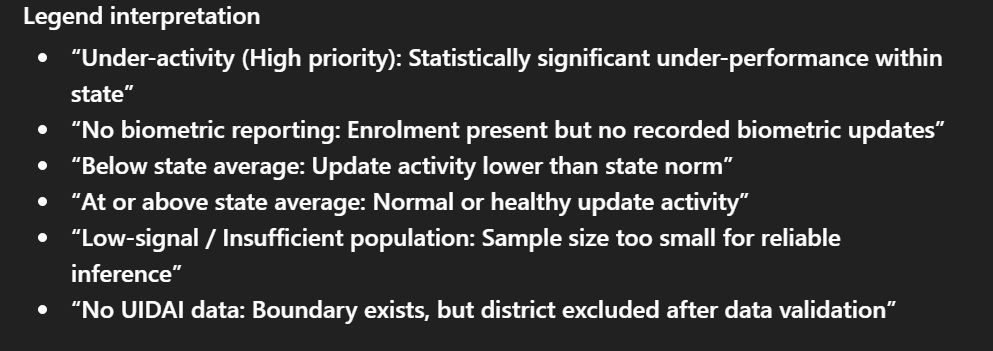

🔴 ZONE 1: Under-activity (High priority)
Insights you can generate

These districts are clear outliers within their own states.

Their biometric update activity is significantly lower than comparable districts.

They are few in number, which makes focused action possible.

They are statistically valid, not small-data noise.

Why this zone matters

This zone highlights where immediate administrative attention is justified.

🟥 ZONE 2: No biometric reporting
Insights you can generate

These districts differ structurally, not just in performance.

The issue is absence of reported activity, not low activity.

They cannot be compared meaningfully with other districts.

Why this zone matters

This zone helps separate data/reporting issues from performance issues.

🟠 ZONE 3: Below state average
Insights you can generate

Many districts perform slightly below their state norm.

Being in this zone does not mean failure, only relative under-performance.

This zone represents potential improvement areas, not emergencies.

Why this zone matters

It supports preventive monitoring rather than corrective action.

🟢 ZONE 4: At or above state average
Insights you can generate

These districts form the functional baseline for their states.

They show that normal biometric update activity exists in every state.

They can act as reference points for state-level comparison.

Why this zone matters

This zone defines what “normal” looks like within each state.

⚪ ZONE 5: Low-signal (small population)
Insights you can generate

Data volume here is too low for reliable conclusions.

Any ranking or comparison would be statistically weak.

These districts require non-quantitative review methods.

Why this zone matters

It prevents false positives and misleading policy decisions.

⚪ ZONE 6: Insufficient eligible population
Insights you can generate

The population eligible for biometric updates is too small to assess.

Low activity here is expected, not abnormal.

These districts should not influence performance evaluation.

Why this zone matters

It protects the analysis from misinterpretation of valid edge cases.

⚪ ZONE 7: No UIDAI data (mapped boundary only)
Insights you can generate

These districts are present geographically but excluded analytically.

The absence is due to data scope or boundary limitations, not behaviour.

Spatial completeness does not always mean analytical completeness.

Why this zone matters

It shows transparent handling of data limitations.

In [ ]:
pip install streamlit plotly geopandas

In [ ]:
# Select only the columns needed for hover
hover_cols = [
    'district_norm',
    'bio_update_rate',
    'z_score',
    'comparable_enrolments'
]

gdf_map = gdf_map.merge(
    district_df[hover_cols],
    on='district_norm',
    how='left'
)


Just for testing purpose

In [ ]:
print(enrollment_df_aggregated.columns)
print(biometric_df_aggregated.columns)


In [ ]:
merge_keys = ['date', 'state_final', 'district', 'pincode']

merged_enrol_bio = enrollment_df_aggregated.merge(
    biometric_df_aggregated[
        merge_keys + ['biometric_updates']
    ],
    on=merge_keys,
    how='left'
)


In [ ]:
print(len(enrollment_df_aggregated),
      len(merged_enrol_bio))


In [ ]:
merge_keys = ['date', 'state_final', 'district', 'pincode']

bio_dupes = biometric_df_aggregated[
    biometric_df_aggregated.duplicated(subset=merge_keys, keep=False)
]

print("Duplicate biometric rows:", len(bio_dupes))


In [ ]:
biometric_df_fixed = (
    biometric_df_aggregated
    .groupby(merge_keys, as_index=False)
    .agg(
        biometric_updates=('biometric_updates', 'sum')
    )
)

In [ ]:
biometric_df_fixed.duplicated(subset=merge_keys).any()


In [ ]:
merged_enrol_bio = enrollment_df_aggregated.merge(
    biometric_df_fixed,
    on=merge_keys,
    how='left'
)


In [ ]:
print(len(enrollment_df_aggregated),
      len(merged_enrol_bio))


In [ ]:
merged_enrol_bio.head()

##


In [ ]:
merged_enrol_bio['date'] = pd.to_datetime(
    merged_enrol_bio['date'],
    dayfirst=True,
    errors='coerce'
)


In [ ]:
merged_enrol_bio[merged_enrol_bio['date'].isna()]


In [ ]:
district_df = (
    merged_enrol_bio
    .groupby(['state_final', 'district'], as_index=False)
    .agg(
        total_enrolments=('total_enrolments', 'sum'),
        biometric_updates=('biometric_updates', 'sum')
    )
)


In [ ]:
district_df['update_ratio'] = (
    district_df['biometric_updates'] /
    district_df['total_enrolments']
)


In [ ]:
district_df.shape


In [ ]:
district_df.describe()


In [ ]:
district_df[
    district_df['biometric_updates'] >
    district_df['total_enrolments']
].head()


In [ ]:
district_df['state_avg_enrol'] = (
    district_df
    .groupby('state_final')['total_enrolments']
    .transform('mean')
)

district_df['state_avg_update_ratio'] = (
    district_df
    .groupby('state_final')['update_ratio']
    .transform('mean')
)


In [ ]:
district_df['enrol_score'] = (
    district_df['total_enrolments'] /
    district_df['state_avg_enrol']
)

district_df['update_score'] = (
    district_df['update_ratio'] /
    district_df['state_avg_update_ratio']
)


In [ ]:
district_df[['enrol_score','update_score']].describe()


In [ ]:
def assign_zone(row):
    if row['enrol_score'] >= 1 and row['update_score'] >= 1:
        return 'Stable & Well-Served'
    elif row['enrol_score'] >= 1 and row['update_score'] < 1:
        return 'Dormant Aadhaar'
    elif row['enrol_score'] < 1 and row['update_score'] < 1:
        return 'Under-Served'
    else:
        return 'High-Churn / Stress'


In [ ]:
district_df['zone'] = district_df.apply(assign_zone, axis=1)


In [ ]:
district_df['zone'].value_counts()


In [ ]:
district_df.groupby(['state_final', 'zone']).size().unstack(fill_value=0)


In [ ]:
!pip install streamlit plotly geopandas

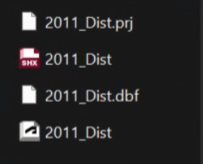

Add above mentioned files from provided drive/repository link

In [ ]:
files.upload()

In [ ]:
##Plotting
import geopandas as gpd

gdf = gpd.read_file("2011_Dist.shp")

print(gdf.shape)
print(gdf.columns)
gdf.head(2)


In [ ]:
gdf['state_final'] = (
    gdf['ST_NM']
    .str.strip()
    .str.title()
)

gdf['district'] = (
    gdf['DISTRICT']
    .str.strip()
    .str.title()
)


In [ ]:
map_df = gdf.merge(
    district_df,
    on=['state_final', 'district'],
    how='left'
)


In [ ]:
map_df['zone'].isna().value_counts()


In [ ]:
up_map = map_df[map_df['state_final'] == 'Uttar Pradesh'].copy()


In [ ]:
up_map['zone'].isna().value_counts()


In [ ]:
uidai_up_districts = set(
    district_df[district_df['state_final'] == 'Uttar Pradesh']['district']
)

geo_up_districts = set(
    up_map['district']
)

sorted(uidai_up_districts - geo_up_districts)[:20]


In [ ]:
sorted(geo_up_districts - uidai_up_districts)[:20]


In [ ]:
up_fix = {
    'Kansiram Nagar': 'Kasganj',
    'Mahamaya Nagar': 'Hathras',
    'Sant Ravi Das Nagar(Bhadohi)': 'Bhadohi'
}

mask_up = (
    (map_df['state_final'] == 'Uttar Pradesh') &
    (map_df['district'].isin(up_fix.keys()))
)

map_df.loc[mask_up, 'district'] = (
    map_df.loc[mask_up, 'district']
    .map(up_fix)
)


In [ ]:
map_df.loc[
    map_df['state_final'] == 'Uttar Pradesh',
    'zone'
].isna().value_counts()


In [ ]:
map_df.loc[
    (map_df['state_final'] == 'Uttar Pradesh') &
    (map_df['zone'].isna()),
    ['district']
]


In [ ]:
up_final = map_df[map_df['state_final'] == 'Uttar Pradesh'].copy()

# centroid for labeling (safe for visualization)
up_final['centroid'] = up_final.geometry.centroid


In [ ]:
label_df = up_final[
    up_final['zone'].isin(['Under-Served', 'High-Churn / Stress'])
]


**


In [ ]:
##NULL Values
demographic_df_clean.isnull().sum()

In [ ]:
enrollment_df_clean.isnull().sum()

In [ ]:
biometric_df_clean.isnull().sum()

In [ ]:
##Datatype fixes
demographic_df_clean.dtypes

In [ ]:
enrollment_df_clean.dtypes

In [ ]:
biometric_df_clean.dtypes

In [ ]:
enrollment_df_clean["date"] = pd.to_datetime(
    enrollment_df_clean["date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [ ]:
enrollment_df_clean.dtypes

In [ ]:
biometric_df_clean["date"] = pd.to_datetime(
    biometric_df_clean["date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [ ]:
biometric_df_clean.dtypes

In [ ]:
demographic_df_clean["date"] = pd.to_datetime(
    demographic_df_clean["date"],
    format="%d-%m-%Y",
    errors="coerce"
)

In [ ]:
demographic_df_clean.dtypes

In [ ]:
#Merging all datasets into one (dataframe) (No practical usecase as of now)
merge_cols = ["date", "state_final", "district", "pincode"]
for name, df in {
    "enrollment": enrollment_df_aggregated,
    "demographic": demographic_df_aggregated,
    "biometric": biometric_df_aggregated
}.items():
    print(name, df.duplicated(subset=merge_cols).sum())

In [ ]:
enrollment_df_clean = enrollment_df_clean.rename(columns={
    "age_0_5": "enroll_age_0_5",
    "age_5_17": "enroll_age_5_17",
    "age_18_greater": "enroll_age_18_greater"
})

In [ ]:
merge_cols = ["date", "state_final", "district", "pincode"]
final_df = (
    enrollment_df_aggregated
    .merge(demographic_df_aggregated, on=merge_cols, how="inner")
    .merge(biometric_df_aggregated, on=merge_cols, how="left")
)

In [ ]:
final_df.shape

In [ ]:
##Fill biometric NaNs with 0 since missing values indicate no recorded events
bio_cols = [c for c in final_df.columns if c.startswith("bio_")]
final_df[bio_cols] = final_df[bio_cols].fillna(0)

In [ ]:
final_df.isna().sum()

In [ ]:
#Saving merged data as csv
final_df.to_csv("uidai_cleaned_combined_data.csv", index=False)

In [ ]:
#files.download("uidai_cleaned_combined_data.csv")